# Crop Pest Swin-Base Classifier
Transfer learning from ImageNet-pretrained Swin-Base on YOLO-cropped pest images

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import os
import time
from tqdm import tqdm

import numpy as np
import torch
from torchvision import transforms, datasets
from torchvision.transforms import InterpolationMode
from torch import nn, optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import timm

from shared import (
    resolve_paths, set_seed, get_device,
    build_classification_dataset, evaluate,
    plot_confusion_matrix, plot_training_curves,
    save_metrics_csv, save_classification_report,
)

PROJECT_ROOT, DATA_ROOT, OUT_ROOT = resolve_paths()

PROJECT_ROOT: f:\github\agro-pest
DATA_ROOT:    f:\github\agro-pest\archive
OUT_ROOT:     f:\github\agro-pest\runs
Data exists:  True


In [2]:
CONFIG = {
    "YOLO_ROOT": DATA_ROOT,
    "OUT_ROOT": OUT_ROOT,

    "CLASS_NAMES": [
        "Ants", "Bees", "Beetles", "Caterpillars", "Earthworms", "Earwigs",
        "Grasshoppers", "Moths", "Slugs", "Snails", "Wasps", "Weevils",
    ],

    "CROP_MARGIN_RATIO": 0.05,
    "MIN_CROP_SIZE": 10,

    "IMG_SIZE": 224,
    "BATCH_SIZE": 16,
    "NUM_WORKERS": 4,
    "EPOCHS": 20,
    "LR": 3e-4,
    "WEIGHT_DECAY": 0.05,
    "SEED": 42,
    "SAVE_BEST_METRIC": "macro_f1",
    "FREEZE_BACKBONE": False,
}

cfg = CONFIG

In [3]:
def get_dataloaders(ds_root, img_size=224, batch=16, workers=4):
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]
    BICUBIC = InterpolationMode.BICUBIC

    tf_train = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.9, 1.0), interpolation=BICUBIC),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10, interpolation=BICUBIC),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std),
    ])
    tf_eval = transforms.Compose([
        transforms.Resize((img_size, img_size), interpolation=BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std),
    ])

    train_ds = datasets.ImageFolder(str(Path(ds_root) / "train"), transform=tf_train)
    valid_ds = datasets.ImageFolder(str(Path(ds_root) / "valid"), transform=tf_eval)
    test_ds = datasets.ImageFolder(str(Path(ds_root) / "test"), transform=tf_eval)

    train_dl = DataLoader(train_ds, batch_size=batch, shuffle=True, num_workers=workers, pin_memory=True)
    valid_dl = DataLoader(valid_ds, batch_size=batch, shuffle=False, num_workers=workers, pin_memory=True)
    test_dl = DataLoader(test_ds, batch_size=batch, shuffle=False, num_workers=workers, pin_memory=True)
    return train_dl, valid_dl, test_dl, train_ds.classes

In [4]:
def create_model(num_classes, freeze_backbone=False):
    model = timm.create_model(
        "swin_base_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes,
    )
    if freeze_backbone:
        for n, p in model.named_parameters():
            if not n.startswith("head"):
                p.requires_grad = False
    return model

In [5]:
set_seed(cfg["SEED"])
device = get_device()
print(f"[device] {device}")

ds_cls_root = build_classification_dataset(
    yolo_root=cfg["YOLO_ROOT"],
    out_root=cfg["OUT_ROOT"],
    class_names=cfg["CLASS_NAMES"],
    margin_ratio=cfg["CROP_MARGIN_RATIO"],
    min_crop=cfg["MIN_CROP_SIZE"],
)

[device] cuda
[build] train: 11502 images


Build train: 100%|██████████| 11502/11502 [03:39<00:00, 52.38it/s] 


[build] valid: 1095 images


Build valid: 100%|██████████| 1095/1095 [00:37<00:00, 29.29it/s]


[build] test: 546 images


Build test: 100%|██████████| 546/546 [00:11<00:00, 47.82it/s] 

[build] Cropped classification dataset at: f:\github\agro-pest\runs\dataset_cls
  train: 15271 samples
  valid: 1341 samples
  test: 689 samples


In [7]:
train_dl, valid_dl, test_dl, classes = get_dataloaders(
    ds_cls_root, img_size=cfg["IMG_SIZE"], batch=cfg["BATCH_SIZE"], workers=cfg["NUM_WORKERS"]
)
print(f"[data] classes: {classes}")

model = create_model(num_classes=len(cfg["CLASS_NAMES"]), freeze_backbone=cfg["FREEZE_BACKBONE"]).to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=cfg["LR"], weight_decay=cfg["WEIGHT_DECAY"])

warmup_epochs = 3
def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        return (current_epoch + 1) / warmup_epochs
    t = (current_epoch - warmup_epochs) / max(1, (cfg["EPOCHS"] - warmup_epochs))
    return 0.5 * (1.0 + np.cos(np.pi * t))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
criterion = nn.CrossEntropyLoss()

best_metric = -1.0
save_dir = Path(cfg["OUT_ROOT"]) / f"swinb_run_{time.strftime('%Y%m%d_%H%M%S')}"
save_dir.mkdir(parents=True, exist_ok=True)
best_w_path = save_dir / "best_swinb.pth"

train_losses, valid_accs, valid_f1s = [], [], []

for epoch in range(1, cfg["EPOCHS"] + 1):
    model.train()
    running_loss = 0.0
    t0 = time.perf_counter()
    pbar = tqdm(train_dl, desc=f"Epoch {epoch:02d}/{cfg['EPOCHS']}", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    scheduler.step()
    train_loss = running_loss / len(train_dl.dataset)

    acc, prec, rec, f1, cm, _, _ = evaluate(model, valid_dl, device, desc="Valid")
    metric = f1 if cfg["SAVE_BEST_METRIC"] == "macro_f1" else acc
    dt = time.perf_counter() - t0
    print(
        f"[epoch {epoch:02d}] {dt:.1f}s | lr={scheduler.get_last_lr()[0]:.2e} "
        f"| train_loss={train_loss:.4f} | valid_acc={acc:.4f} valid_f1={f1:.4f}"
    )

    train_losses.append(train_loss)
    valid_accs.append(acc)
    valid_f1s.append(f1)

    if metric > best_metric:
        best_metric = metric
        torch.save(model.state_dict(), best_w_path)
        print(f"  -> saved best to {best_w_path}")

[data] classes: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

C:\Users\manafeng-local\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\manafeng-local\.cache\huggingface\hub\models--timm--swin_base_patch4_window7_224.ms_in22k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[epoch 01] 259.2s | lr=2.00e-04 | train_loss=0.2697 | valid_acc=0.9157 valid_f1=0.9137
  -> saved best to f:\github\agro-pest\runs\swinb_run_20260429_080611\best_swinb.pth


[epoch 02] 331.9s | lr=3.00e-04 | train_loss=0.3072 | valid_acc=0.8494 valid_f1=0.8465


...

[epoch 16] 132.2s | lr=3.91e-05 | train_loss=0.0061 | valid_acc=0.8702 valid_f1=0.8643


[epoch 17] 132.7s | lr=2.25e-05 | train_loss=0.0032 | valid_acc=0.8658 valid_f1=0.8598


[epoch 18] 132.4s | lr=1.01e-05 | train_loss=0.0020 | valid_acc=0.8762 valid_f1=0.8720


[epoch 19] 132.4s | lr=2.55e-06 | train_loss=0.0017 | valid_acc=0.8829 valid_f1=0.8783


[epoch 20] 132.9s | lr=0.00e+00 | train_loss=0.0006 | valid_acc=0.8814 valid_f1=0.8768


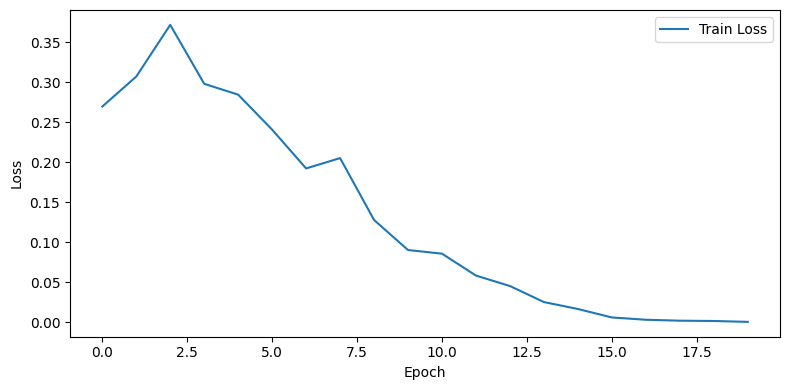

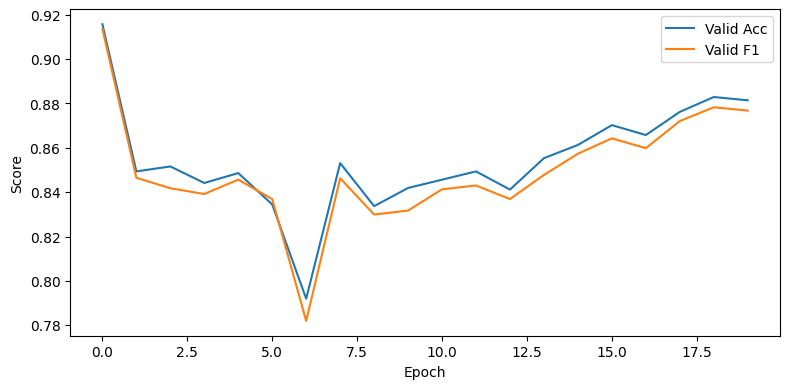

In [8]:
plot_training_curves(train_losses, valid_accs, valid_f1s, save_dir)

Valid: acc=0.9157 prec=0.9177 rec=0.9124 f1=0.9137
Test:  acc=0.9173 prec=0.9227 rec=0.9139 f1=0.9148

Confusion Matrix (Valid):


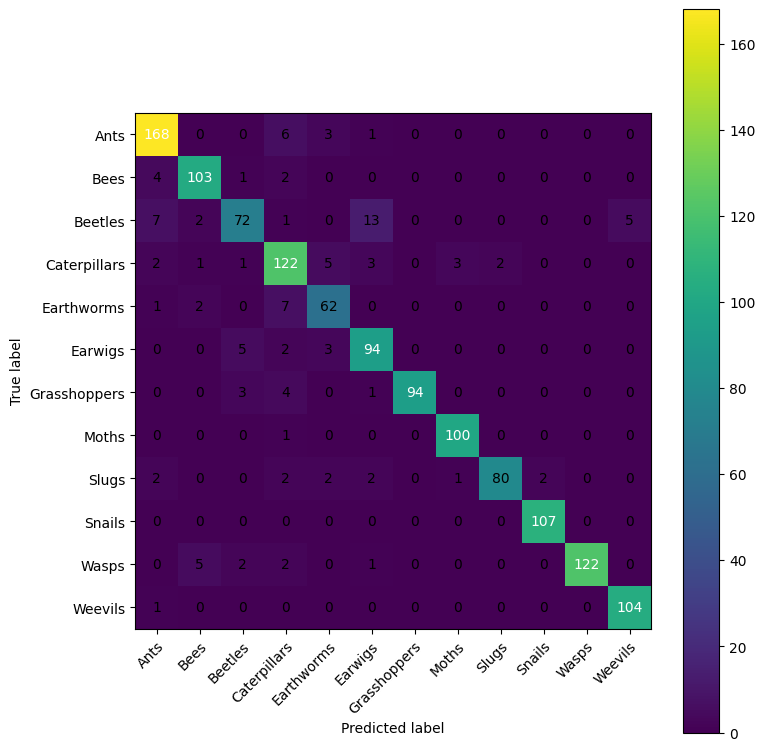


Confusion Matrix (Test):


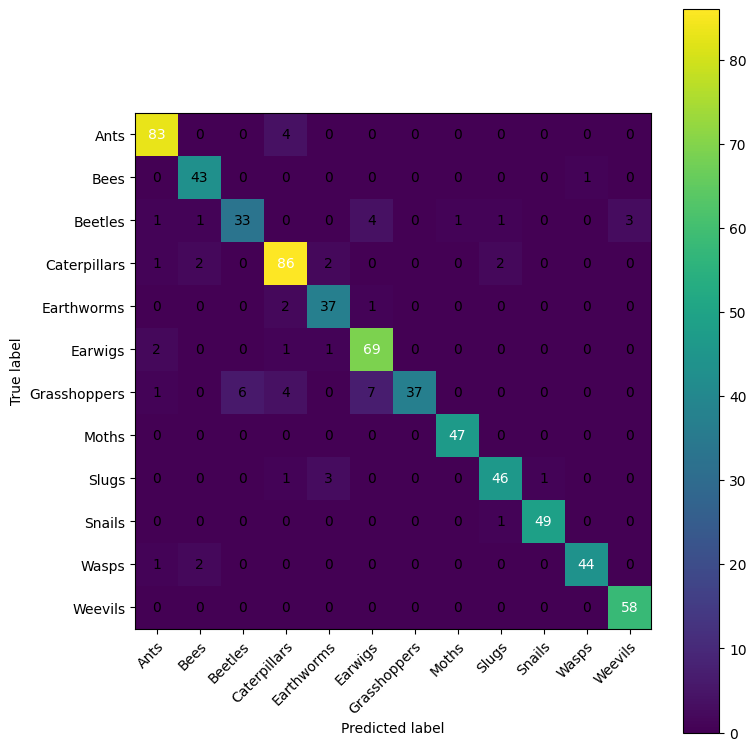


Classification Report (Test):
              precision    recall  f1-score   support

        Ants     0.9326    0.9540    0.9432        87
        Bees     0.8958    0.9773    0.9348        44
     Beetles     0.8462    0.7500    0.7952        44
Caterpillars     0.8776    0.9247    0.9005        93
  Earthworms     0.8605    0.9250    0.8916        40
     Earwigs     0.8519    0.9452    0.8961        73
Grasshoppers     1.0000    0.6727    0.8043        55
       Moths     0.9792    1.0000    0.9895        47
       Slugs     0.9200    0.9020    0.9109        51
      Snails     0.9800    0.9800    0.9800        50
       Wasps     0.9778    0.9362    0.9565        47
     Weevils     0.9508    1.0000    0.9748        58

    accuracy                         0.9173       689
   macro avg     0.9227    0.9139    0.9148       689
weighted avg     0.9202    0.9173    0.9154       689


=== DONE (Swin-Base) ===
Artifacts saved in: f:\github\agro-pest\runs\swinb_run_20260429_080611
  - B

In [9]:
model.load_state_dict(torch.load(best_w_path, map_location=device, weights_only=True))

acc_v, prec_v, rec_v, f1_v, cm_v, _, _ = evaluate(model, valid_dl, device, desc="Valid")
acc_t, prec_t, rec_t, f1_t, cm_t, y_true_t, y_pred_t = evaluate(model, test_dl, device, desc="Test")

print(f"Valid: acc={acc_v:.4f} prec={prec_v:.4f} rec={rec_v:.4f} f1={f1_v:.4f}")
print(f"Test:  acc={acc_t:.4f} prec={prec_t:.4f} rec={rec_t:.4f} f1={f1_t:.4f}")

print("\nConfusion Matrix (Valid):")
plot_confusion_matrix(cm_v, classes, save_dir / "cm_valid.png")
print("\nConfusion Matrix (Test):")
plot_confusion_matrix(cm_t, classes, save_dir / "cm_test.png")

print("\nClassification Report (Test):")
print(classification_report(y_true_t, y_pred_t, target_names=classes, digits=4))

metrics_csv = save_metrics_csv(save_dir, acc_v, prec_v, rec_v, f1_v, acc_t, prec_t, rec_t, f1_t)
report_txt = save_classification_report(save_dir, y_true_t, y_pred_t, classes)

print("\n=== DONE (Swin-Base) ===")
print(f"Artifacts saved in: {save_dir}")
print(f"  - Best weights: {best_w_path}")
print(f"  - Valid CM:     {save_dir / 'cm_valid.png'}")
print(f"  - Test  CM:     {save_dir / 'cm_test.png'}")
print(f"  - Metrics :     {metrics_csv}")
print(f"  - Report  :     {report_txt}")